# Approach 4: VAD + WhisperX ASR + WhisperX Diarization

This notebook implements the transcript-aware approach using **WhisperX**.

Pipeline:
1. Load each audio file with `whisperx.load_audio`.
2. Use **Silero VAD** to generate candidate conversation windows.
3. Run **WhisperX ASR** on the full audio file.
4. Run **WhisperX alignment** for tighter segment/word timestamps when an aligner is available.
5. Run **WhisperX diarization** to assign anonymous speakers to transcript words/segments.
6. Score each VAD candidate using transcript cues plus speaker-turn cues.
7. Export the final predicted two customer conversations for each audio file.

No merged speaker audio files are created. The diarization output is used only as metadata for scoring candidate conversation windows.


In [1]:
# Run this once in a fresh environment if needed.
# %pip install -q git+https://github.com/m-bain/whisperx.git faster-whisper silero-vad matplotlib pandas ipython python-dotenv
# If whisperx.load_audio fails with FileNotFoundError: 'ffmpeg', install ffmpeg in the system environment.
# Lightning/conda example: conda install -y -c conda-forge ffmpeg
# WhisperX/pyannote diarization needs HF_TOKEN and accepted pyannote model terms on Hugging Face.


In [2]:
from __future__ import annotations

import gc
import os
import re
import shutil
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".mpl_cache").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from silero_vad import get_speech_timestamps, load_silero_vad

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

try:
    import whisperx
    WHISPERX_AVAILABLE = True
    WHISPERX_IMPORT_ERROR = None
except ModuleNotFoundError as exc:
    whisperx = None
    WHISPERX_AVAILABLE = False
    WHISPERX_IMPORT_ERROR = exc
    print("WhisperX is not installed. Run the install cell before running this notebook.")

try:
    from faster_whisper.audio import decode_audio as fw_decode_audio
    FW_AUDIO_AVAILABLE = True
    FW_AUDIO_IMPORT_ERROR = None
except ModuleNotFoundError as exc:
    fw_decode_audio = None
    FW_AUDIO_AVAILABLE = False
    FW_AUDIO_IMPORT_ERROR = exc
    print("faster-whisper audio decoder is not installed. It will only be needed if ffmpeg CLI is missing.")

torch.set_num_threads(1)


In [3]:
from dotenv import load_dotenv
load_dotenv()


def ensure_whisperx_available():
    if not WHISPERX_AVAILABLE:
        raise ModuleNotFoundError(
            "WhisperX is not installed. Run `%pip install -q git+https://github.com/m-bain/whisperx.git silero-vad matplotlib pandas ipython python-dotenv`."
        ) from WHISPERX_IMPORT_ERROR


def validate_runtime_dependencies():
    try:
        _ = torch.tensor([1.0]).cpu().numpy()
    except Exception as exc:
        raise RuntimeError(
            "PyTorch cannot use NumPy in the current kernel. Restart the kernel after installing compatible torch/numpy versions."
        ) from exc


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        has_audio = (candidate / "audio").exists()
        has_repo_marker = (candidate / "ground_truth.json").exists() or (candidate / "approaches").exists() or (candidate / "context.md").exists()
        if has_audio and has_repo_marker:
            return candidate
        # If the notebook is launched from inside approaches/, the parent is the project root.
        if candidate.name == "approaches" and (candidate.parent / "audio").exists():
            return candidate.parent
    raise FileNotFoundError(
        "Could not find project root. Expected a folder containing audio/ and ground_truth.json or approaches/. "
        f"Current working directory was: {start}"
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OUTPUT_DIR = PROJECT_ROOT / "approaches" / "approach_4_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "audio_dir": PROJECT_ROOT / "audio",
    "output_dir": OUTPUT_DIR,
    "target_sr": 16000,
    "threshold": 0.5,
    "min_speech_duration_ms": 250,
    "max_speech_duration_s": float("inf"),
    "min_silence_duration_ms": 400,
    "speech_pad_ms": 200,
    "merge_gap_s": 1.0,
    "min_region_s": 1.5,
    "conversation_gap_s": 5.0,
    "candidate_bridge_gap_s": 20.0,
    "min_bridge_speaker_jaccard": 0.5,
    "min_bridge_tokens": 8,
    "whisperx_model_size": "small",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "compute_type": "float16" if torch.cuda.is_available() else "int8",
    "batch_size": 8 if torch.cuda.is_available() else 4,
    "run_alignment": True,
    "run_diarization": True,
    "min_speakers": 2,
    "max_speakers": 4,
    "expected_conversations": 2,
    "min_final_conversation_s": 8.0,
    "plot_width": 18,
    "plot_height": 4,
    "retail_keywords": [
        "price", "rate", "design", "item", "product", "gold", "ring", "chain", "bangle", "necklace",
        "earring", "gram", "bill", "discount", "size", "color", "weight", "making", "diamond", "silver",
        "model", "piece", "show", "see", "take", "buy", "order", "return", "exchange", "cash", "credit"
    ],
    "customer_cues": [
        "sir", "madam", "please", "look", "show", "which", "what", "how much", "can i", "do you", "want"
    ],
}

HF_TOKEN = os.getenv("HF_TOKEN")
audio_files = sorted(CONFIG["audio_dir"].glob("*.mp3")) + sorted(CONFIG["audio_dir"].glob("*.wav"))

print("Project root:", PROJECT_ROOT)
print("Audio dir:", CONFIG["audio_dir"])
print("Audio files:", [path.name for path in audio_files])
print("Outputs:", OUTPUT_DIR)
print("Device:", CONFIG["device"])
print("Compute type:", CONFIG["compute_type"])
print("WhisperX model:", CONFIG["whisperx_model_size"])
print("HF token present:", bool(HF_TOKEN))

import sys
sys.path.append(str(PROJECT_ROOT / "approaches"))
from output_utils import load_ground_truth, export_uniform_outputs, export_combined_outputs

GROUND_TRUTH = load_ground_truth(PROJECT_ROOT)


Project root: /teamspace/studios/this_studio
Audio dir: /teamspace/studios/this_studio/audio
Audio files: ['Sample1KN.mp3', 'Sample2EN.mp3', 'sample3KN.mp3']
Outputs: /teamspace/studios/this_studio/approaches/approach_4_outputs
Device: cpu
Compute type: int8
WhisperX model: small
HF token present: True


In [4]:
def format_time(seconds: float) -> str:
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:02d}:{secs:06.3f}"


def add_readable_times(rows: list[dict]):
    for row in rows:
        row["start_hms"] = format_time(row["start"])
        row["end_hms"] = format_time(row["end"])
    return rows


def load_audio_mono_resampled(path: str | Path, target_sr: int = 16000):
    path = Path(path)

    if shutil.which("ffmpeg") is not None:
        audio = whisperx.load_audio(str(path))
    else:
        if not FW_AUDIO_AVAILABLE:
            raise RuntimeError(
                "WhisperX audio loading requires the ffmpeg command-line binary, but it is not installed. "
                "Install it with `conda install -y -c conda-forge ffmpeg`, or install faster-whisper for the PyAV fallback."
            ) from FW_AUDIO_IMPORT_ERROR
        print("ffmpeg CLI not found; loading audio with faster-whisper/PyAV fallback.")
        audio = fw_decode_audio(str(path), sampling_rate=target_sr)

    audio = np.asarray(audio, dtype=np.float32)
    waveform = torch.from_numpy(audio).float().contiguous()
    return waveform, target_sr, audio


VAD_MODEL = load_silero_vad()


def run_silero_vad_on_tensor(waveform: torch.Tensor, sr: int, cfg: dict):
    speech = get_speech_timestamps(
        waveform,
        VAD_MODEL,
        sampling_rate=sr,
        threshold=cfg["threshold"],
        min_speech_duration_ms=cfg["min_speech_duration_ms"],
        max_speech_duration_s=cfg["max_speech_duration_s"],
        min_silence_duration_ms=cfg["min_silence_duration_ms"],
        speech_pad_ms=cfg["speech_pad_ms"],
        return_seconds=False,
    )

    return [
        {
            "segment_id": idx + 1,
            "start": seg["start"] / sr,
            "end": seg["end"] / sr,
            "duration": (seg["end"] - seg["start"]) / sr,
        }
        for idx, seg in enumerate(speech)
    ]


def merge_close_segments(segments: list[dict], merge_gap_s: float, min_region_s: float):
    if not segments:
        return []

    merged = []
    current = {"start": segments[0]["start"], "end": segments[0]["end"]}

    for seg in segments[1:]:
        if seg["start"] - current["end"] <= merge_gap_s:
            current["end"] = max(current["end"], seg["end"])
        else:
            current["duration"] = current["end"] - current["start"]
            if current["duration"] >= min_region_s:
                merged.append(current)
            current = {"start": seg["start"], "end": seg["end"]}

    current["duration"] = current["end"] - current["start"]
    if current["duration"] >= min_region_s:
        merged.append(current)

    return [
        {"region_id": idx + 1, "start": seg["start"], "end": seg["end"], "duration": seg["duration"]}
        for idx, seg in enumerate(merged)
    ]


def assign_conversation_ids(regions: list[dict], conversation_gap_s: float):
    rows = []
    conversation_id = 1
    previous_end = None

    for region in regions:
        if previous_end is not None and region["start"] - previous_end > conversation_gap_s:
            conversation_id += 1
        row = region.copy()
        row["conversation_id"] = conversation_id
        rows.append(row)
        previous_end = region["end"]

    return rows


def collapse_conversation_groups(region_rows: list[dict]):
    if not region_rows:
        return []

    grouped = []
    current_id = region_rows[0]["conversation_id"]
    current_start = region_rows[0]["start"]
    current_end = region_rows[0]["end"]
    region_count = 1

    for row in region_rows[1:]:
        if row["conversation_id"] == current_id:
            current_end = max(current_end, row["end"])
            region_count += 1
        else:
            grouped.append({"conversation_id": current_id, "start": current_start, "end": current_end, "duration": current_end - current_start, "num_regions": region_count})
            current_id = row["conversation_id"]
            current_start = row["start"]
            current_end = row["end"]
            region_count = 1

    grouped.append({"conversation_id": current_id, "start": current_start, "end": current_end, "duration": current_end - current_start, "num_regions": region_count})
    return grouped


In [5]:
def load_whisperx_model(cfg: dict):
    return whisperx.load_model(
        cfg["whisperx_model_size"],
        cfg["device"],
        compute_type=cfg["compute_type"],
    )


def maybe_align_whisperx_result(result: dict, audio_np: np.ndarray, cfg: dict):
    if not cfg["run_alignment"]:
        return result
    if "language" not in result or result["language"] is None:
        return result

    try:
        model_a, metadata = whisperx.load_align_model(language_code=result["language"], device=cfg["device"])
        aligned = whisperx.align(
            result["segments"],
            model_a,
            metadata,
            audio_np,
            cfg["device"],
            return_char_alignments=False,
        )
        aligned["language"] = result.get("language")
        del model_a
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return aligned
    except Exception as exc:
        print(f"Alignment failed for language {result.get('language')}: {exc}. Continuing with raw WhisperX segments.")
        return result


def maybe_diarize_and_assign(result: dict, audio_np: np.ndarray, cfg: dict, hf_token: str | None):
    if not cfg["run_diarization"]:
        return result, pd.DataFrame()
    if not hf_token:
        print("HF_TOKEN is not set. Skipping WhisperX diarization.")
        return result, pd.DataFrame()

    try:
        diarize_model = whisperx.DiarizationPipeline(use_auth_token=hf_token, device=cfg["device"])
        diarize_segments = diarize_model(audio_np, min_speakers=cfg["min_speakers"], max_speakers=cfg["max_speakers"])
        assigned = whisperx.assign_word_speakers(diarize_segments, result)
        del diarize_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return assigned, diarize_segments
    except Exception as exc:
        print(f"WhisperX diarization failed: {exc}. Continuing without speaker labels.")
        return result, pd.DataFrame()


def whisperx_segments_to_rows(result: dict):
    rows = []
    for idx, seg in enumerate(result.get("segments", []), start=1):
        start = float(seg.get("start", 0.0))
        end = float(seg.get("end", start))
        text = str(seg.get("text", "")).strip()
        speaker = seg.get("speaker")

        word_speakers = [word.get("speaker") for word in seg.get("words", []) if word.get("speaker")]
        if speaker is None and word_speakers:
            speaker = max(set(word_speakers), key=word_speakers.count)

        rows.append(
            {
                "asr_segment_id": idx,
                "start": start,
                "end": end,
                "duration": max(0.0, end - start),
                "text": text,
                "speaker": speaker,
                "language": result.get("language"),
            }
        )
    return add_readable_times(rows)


def diarization_to_rows(diarize_segments):
    if diarize_segments is None or len(diarize_segments) == 0:
        return []

    df = pd.DataFrame(diarize_segments)
    rows = []
    for idx, row in df.iterrows():
        start = float(row["start"])
        end = float(row["end"])
        rows.append(
            {
                "turn_id": idx + 1,
                "speaker": row.get("speaker"),
                "start": start,
                "end": end,
                "duration": max(0.0, end - start),
            }
        )
    return add_readable_times(rows)


In [6]:
def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", text.lower().strip())


def count_phrase_hits(text: str, phrases: list[str]) -> int:
    return sum(1 for phrase in phrases if phrase in text)


def overlaps(row: dict, start: float, end: float) -> bool:
    return row["start"] < end and row["end"] > start


def rows_overlapping_window(rows: list[dict], start: float, end: float):
    return [row for row in rows if overlaps(row, start, end)]


def summarize_candidate(candidate: dict, asr_rows: list[dict], diarization_rows: list[dict], cfg: dict):
    candidate_asr = rows_overlapping_window(asr_rows, candidate["start"], candidate["end"])
    candidate_turns = rows_overlapping_window(diarization_rows, candidate["start"], candidate["end"])
    transcript = " ".join(row["text"] for row in candidate_asr if row.get("text"))
    normalized = normalize_text(transcript)
    tokens = re.findall(r"\b\w+\b", normalized)
    speakers = [row.get("speaker") for row in candidate_turns if row.get("speaker")]
    asr_speakers = [row.get("speaker") for row in candidate_asr if row.get("speaker")]
    speaker_sequence = speakers or asr_speakers
    unique_speakers = sorted(set(speaker_sequence))
    speaker_switches = sum(1 for prev, cur in zip(speaker_sequence, speaker_sequence[1:]) if prev != cur)
    retail_hits = count_phrase_hits(normalized, cfg["retail_keywords"])
    customer_cue_hits = count_phrase_hits(normalized, cfg["customer_cues"])
    number_hits = len(re.findall(r"\b\d+[a-z]*\b", normalized))
    token_count = len(tokens)
    segment_count = len(candidate_asr)
    turn_count = len(candidate_turns)
    transcript_density = token_count / max(candidate["duration"], 1e-6)

    interaction_like = (
        candidate["duration"] >= 15.0
        and token_count >= 10
        and (len(unique_speakers) >= 2 or segment_count >= 2)
        and (retail_hits + customer_cue_hits + number_hits) >= 1
    )

    score = 0.0
    score += min(candidate["duration"], 180.0) / 45.0
    score += min(token_count, 120) / 12.0
    score += min(segment_count, 12) * 0.45
    score += min(len(unique_speakers), 3) * 1.6
    score += min(speaker_switches, 10) * 0.5
    score += min(retail_hits, 8) * 1.0
    score += min(customer_cue_hits, 6) * 0.8
    score += min(number_hits, 5) * 0.6

    if token_count < 6:
        score -= 3.0
    if candidate["duration"] < 8.0:
        score -= 3.0
    if segment_count == 0:
        score -= 5.0

    summary = {
        "conversation_id": candidate["conversation_id"],
        "start": candidate["start"],
        "end": candidate["end"],
        "duration": candidate["duration"],
        "num_regions": candidate["num_regions"],
        "segment_count": segment_count,
        "turn_count": turn_count,
        "num_speakers": len(unique_speakers),
        "speaker_set": "|".join(unique_speakers),
        "speaker_switches": speaker_switches,
        "token_count": token_count,
        "retail_hits": retail_hits,
        "customer_cue_hits": customer_cue_hits,
        "number_hits": number_hits,
        "transcript_density": transcript_density,
        "interaction_like": interaction_like,
        "conversation_score": round(score, 3),
        "transcript": transcript,
    }
    return add_readable_times([summary])[0]


def speaker_set(row: dict) -> set[str]:
    speakers = row.get("speaker_set", "")
    if not speakers:
        return set()
    return {speaker for speaker in speakers.split("|") if speaker}


def speaker_jaccard(left: dict, right: dict) -> float:
    left_speakers = speaker_set(left)
    right_speakers = speaker_set(right)
    if not left_speakers or not right_speakers:
        return 0.0
    return len(left_speakers & right_speakers) / len(left_speakers | right_speakers)


def should_bridge_candidates(left: dict, right: dict, cfg: dict) -> tuple[bool, str]:
    gap = right["start"] - left["end"]
    if gap < 0:
        return True, "overlap"
    if gap > cfg["candidate_bridge_gap_s"]:
        return False, "gap_too_large"

    left_substantive = left["token_count"] >= cfg["min_bridge_tokens"] or left["interaction_like"]
    right_substantive = right["token_count"] >= cfg["min_bridge_tokens"] or right["interaction_like"]
    if not (left_substantive and right_substantive):
        return False, "not_substantive"

    jaccard = speaker_jaccard(left, right)
    if jaccard >= cfg["min_bridge_speaker_jaccard"]:
        return True, f"same_speaker_set_jaccard_{jaccard:.2f}"

    # Fallback for cases where diarization is unavailable or speaker labels are missing:
    # merge only when both sides look like the same retail/customer discussion.
    left_semantic = left["retail_hits"] + left["customer_cue_hits"] + left["number_hits"]
    right_semantic = right["retail_hits"] + right["customer_cue_hits"] + right["number_hits"]
    if jaccard == 0.0 and left_semantic > 0 and right_semantic > 0 and gap <= cfg["candidate_bridge_gap_s"] / 2:
        return True, "semantic_continuity_no_speaker_labels"

    return False, f"speaker_change_jaccard_{jaccard:.2f}"


def merge_candidate_pair(left: dict, right: dict, reason: str) -> dict:
    source_ids = []
    for row in (left, right):
        existing = row.get("source_conversation_ids")
        if existing:
            source_ids.extend(str(existing).split("|"))
        else:
            source_ids.append(str(row["conversation_id"]))
    source_ids = list(dict.fromkeys(source_ids))

    speakers = sorted(speaker_set(left) | speaker_set(right))
    duration = right["end"] - left["start"]
    token_count = left["token_count"] + right["token_count"]
    segment_count = left["segment_count"] + right["segment_count"]
    turn_count = left["turn_count"] + right["turn_count"]
    speaker_switches = left["speaker_switches"] + right["speaker_switches"]
    retail_hits = left["retail_hits"] + right["retail_hits"]
    customer_cue_hits = left["customer_cue_hits"] + right["customer_cue_hits"]
    number_hits = left["number_hits"] + right["number_hits"]
    transcript = " ".join(part for part in [left.get("transcript", ""), right.get("transcript", "")] if part)
    bridge_reasons = "|".join(part for part in [left.get("bridge_reasons", ""), reason] if part)

    score = 0.0
    score += min(duration, 300.0) / 45.0
    score += min(token_count, 200) / 12.0
    score += min(segment_count, 20) * 0.45
    score += min(len(speakers), 3) * 1.6
    score += min(speaker_switches, 16) * 0.5
    score += min(retail_hits, 12) * 1.0
    score += min(customer_cue_hits, 8) * 0.8
    score += min(number_hits, 8) * 0.6

    merged = {
        "conversation_id": int(source_ids[0]),
        "source_conversation_ids": "|".join(source_ids),
        "start": left["start"],
        "end": right["end"],
        "duration": duration,
        "num_regions": left["num_regions"] + right["num_regions"],
        "segment_count": segment_count,
        "turn_count": turn_count,
        "num_speakers": len(speakers),
        "speaker_set": "|".join(speakers),
        "speaker_switches": speaker_switches,
        "token_count": token_count,
        "retail_hits": retail_hits,
        "customer_cue_hits": customer_cue_hits,
        "number_hits": number_hits,
        "transcript_density": token_count / max(duration, 1e-6),
        "interaction_like": left["interaction_like"] or right["interaction_like"],
        "conversation_score": round(score, 3),
        "bridge_reasons": bridge_reasons,
        "transcript": transcript,
    }
    return add_readable_times([merged])[0]


def merge_related_candidate_summaries(candidate_summaries: list[dict], cfg: dict):
    if not candidate_summaries:
        return []

    ordered = sorted(candidate_summaries, key=lambda row: row["start"])
    merged = [ordered[0].copy()]

    for current in ordered[1:]:
        should_merge, reason = should_bridge_candidates(merged[-1], current, cfg)
        if should_merge:
            merged[-1] = merge_candidate_pair(merged[-1], current, reason)
        else:
            row = current.copy()
            row.setdefault("source_conversation_ids", str(row["conversation_id"]))
            row.setdefault("bridge_reasons", "")
            merged.append(row)

    for row in merged:
        row.setdefault("source_conversation_ids", str(row["conversation_id"]))
        row.setdefault("bridge_reasons", "")

    return merged


def select_final_two_conversations(candidate_summaries: list[dict], expected_count: int, min_duration_s: float):
    eligible = [row for row in candidate_summaries if row["duration"] >= min_duration_s] or list(candidate_summaries)
    primary = sorted([row for row in eligible if row["interaction_like"]], key=lambda row: (-row["conversation_score"], row["start"]))
    selected = primary[:expected_count]
    if len(selected) < expected_count:
        selected_ids = {row["conversation_id"] for row in selected}
        fallback = [row for row in sorted(eligible, key=lambda row: (-row["conversation_score"], row["start"])) if row["conversation_id"] not in selected_ids]
        selected.extend(fallback[: expected_count - len(selected)])
    selected = sorted(selected[:expected_count], key=lambda row: row["start"])
    return [{**row, "customer_index": idx} for idx, row in enumerate(selected, start=1)]


In [7]:
def plot_waveform_with_selected_conversations(waveform, sr, candidates, selected, title):
    times = np.arange(len(waveform)) / sr
    peak = max(float(waveform.abs().max()), 1e-6)

    plt.figure(figsize=(CONFIG["plot_width"], CONFIG["plot_height"]))
    plt.plot(times, waveform.numpy(), linewidth=0.5, color="steelblue")
    for candidate in candidates:
        plt.axvspan(candidate["start"], candidate["end"], alpha=0.10, color="gray")
    for row in selected:
        plt.axvspan(row["start"], row["end"], alpha=0.30, color="tab:green")
        plt.text(row["start"], peak * 0.8, f"Customer {row['customer_index']}", fontsize=10)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


def export_result_tables(result: dict, output_dir: Path):
    exported = export_uniform_outputs(
        output_dir=output_dir,
        audio_name=result["audio_name"],
        approach_name="approach_4_whisperx",
        conversation_candidates=pd.DataFrame(result["conversation_candidates"]),
        final_two=pd.DataFrame(result.get("final_two_conversations", [])),
        ground_truth=GROUND_TRUTH,
        final_selection_method="whisperx_semantic_bridge_score",
    )

    # Detailed artifacts are useful for approach 5 but kept out of the main output folder.
    debug_dir = output_dir / "_debug"
    debug_dir.mkdir(parents=True, exist_ok=True)
    stem = Path(result["audio_name"]).stem
    pd.DataFrame(result["asr_segments"]).to_csv(debug_dir / f"{stem}_whisperx_asr_segments.csv", index=False)
    pd.DataFrame(result["speaker_turns"]).to_csv(debug_dir / f"{stem}_whisperx_speaker_turns.csv", index=False)
    pd.DataFrame(result["candidate_summaries"]).to_csv(debug_dir / f"{stem}_whisperx_candidate_summary.csv", index=False)
    pd.DataFrame(result["merged_candidate_summaries"]).to_csv(debug_dir / f"{stem}_whisperx_merged_candidate_summary.csv", index=False)
    return exported


def process_audio_file(audio_path: str | Path, cfg: dict, asr_model):
    waveform, sr, audio_np = load_audio_mono_resampled(audio_path, target_sr=cfg["target_sr"])

    speech_segments = add_readable_times(run_silero_vad_on_tensor(waveform, sr, cfg))
    merged_regions = add_readable_times(merge_close_segments(speech_segments, cfg["merge_gap_s"], cfg["min_region_s"]))
    region_rows = assign_conversation_ids(merged_regions, cfg["conversation_gap_s"])
    conversation_candidates = add_readable_times(collapse_conversation_groups(region_rows))

    print("  WhisperX transcription...")
    whisperx_result = asr_model.transcribe(audio_np, batch_size=cfg["batch_size"])
    whisperx_result = maybe_align_whisperx_result(whisperx_result, audio_np, cfg)
    whisperx_result, diarize_segments = maybe_diarize_and_assign(whisperx_result, audio_np, cfg, HF_TOKEN)

    asr_rows = whisperx_segments_to_rows(whisperx_result)
    speaker_rows = diarization_to_rows(diarize_segments)
    candidate_summaries = [summarize_candidate(candidate, asr_rows, speaker_rows, cfg) for candidate in conversation_candidates]
    merged_candidate_summaries = merge_related_candidate_summaries(candidate_summaries, cfg)
    final_two_conversations = add_readable_times(select_final_two_conversations(merged_candidate_summaries, cfg["expected_conversations"], cfg["min_final_conversation_s"]))

    return {
        "audio_path": str(audio_path),
        "audio_name": Path(audio_path).name,
        "sample_rate": sr,
        "duration_s": len(waveform) / sr,
        "language": whisperx_result.get("language"),
        "waveform": waveform,
        "speech_segments": speech_segments,
        "merged_regions": merged_regions,
        "conversation_candidates": conversation_candidates,
        "asr_segments": asr_rows,
        "speaker_turns": speaker_rows,
        "candidate_summaries": candidate_summaries,
        "merged_candidate_summaries": merged_candidate_summaries,
        "final_two_conversations": final_two_conversations,
    }


In [8]:
asr_model = load_whisperx_model(CONFIG)

results = []
for path in audio_files:
    print(f"Processing {path.name}...")
    result = process_audio_file(path, CONFIG, asr_model)
    results.append(result)

summary_rows = []
final_rows = []
exported_outputs = []
for result in results:
    exported_outputs.append(export_result_tables(result, OUTPUT_DIR))
    summary_rows.append(
        {
            "audio_name": result["audio_name"],
            "language": result["language"],
            "duration_s": round(result["duration_s"], 2),
            "conversation_candidates": len(result["conversation_candidates"]),
            "selected_final_conversations": len(result["final_two_conversations"]),
        }
    )
    for row in result["final_two_conversations"]:
        out = row.copy()
        out["audio_name"] = result["audio_name"]
        final_rows.append(out)

summary_df = pd.DataFrame(summary_rows)
final_summary_df = pd.DataFrame(final_rows)
final_summary_df.to_csv(OUTPUT_DIR / "all_files_final_two_conversations.csv", index=False)

combined_outputs = export_combined_outputs(CONFIG["output_dir"] if "CONFIG" in globals() else OUTPUT_DIR, exported_outputs)

display(summary_df)
display(final_summary_df)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyannote/audio/core/io.py:47: UserWarning: 
torchcodec is not installed correctly so built-in audio decoding will fail. Solutions are:
* use audio preloaded in-memory as a {'waveform': (channel, time) torch.Tensor, 'sample_rate': int} dictionary;
* fix torchcodec installation. Error message was:

Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6 and 7.
          2. The PyTorch version (2.8.0+cu128) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.
        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 7: lib

2026-04-15 15:15:02 - whisperx.asr - INFO - No language specified, language will be detected for each audio file (increases inference time)
2026-04-15 15:15:02 - whisperx.vads.pyannote - INFO - Performing voice activity detection using Pyannote...


Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.0. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../../../../home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/whisperx/assets/pytorch_model.bin`


Processing Sample1KN.mp3...
ffmpeg CLI not found; loading audio with faster-whisper/PyAV fallback.
  WhisperX transcription...
2026-04-15 15:15:50 - whisperx.asr - INFO - Detected language: kn (0.54) in first 30s of audio
2026-04-15 15:18:11 - whisperx.alignment - ERROR - No default alignment model for language: kn. Please find a wav2vec2.0 model finetuned on this language at https://huggingface.co/models, then pass the model name via --align_model [MODEL_NAME]
Alignment failed for language kn: No default align-model for language: kn. Continuing with raw WhisperX segments.
WhisperX diarization failed: module 'whisperx' has no attribute 'DiarizationPipeline'. Continuing without speaker labels.
Processing Sample2EN.mp3...
ffmpeg CLI not found; loading audio with faster-whisper/PyAV fallback.
  WhisperX transcription...
2026-04-15 15:19:19 - whisperx.asr - INFO - Detected language: en (0.76) in first 30s of audio
WhisperX diarization failed: module 'whisperx' has no attribute 'Diarization

,audio_name,language,duration_s,conversation_candidates,selected_final_conversations
0,Sample1KN.mp3,kn,661.8,14,2
1,Sample2EN.mp3,en,921.7,19,2
2,sample3KN.mp3,kn,362.5,7,2


,conversation_id,start,end,duration,num_regions,segment_count,turn_count,num_speakers,speaker_set,speaker_switches,...,transcript_density,interaction_like,conversation_score,transcript,start_hms,end_hms,source_conversation_ids,bridge_reasons,customer_index,audio_name
0,6,267.992,308.392,40.400,2,3,0,0,,0,...,2.326733,False,10.081,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ...,04:27.992,05:08.392,6,,1,Sample1KN.mp3
1,13,580.952,626.472,45.520,4,2,0,0,,0,...,2.943761,True,18.112,ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸ...,09:40.952,10:26.472,13,,2,Sample1KN.mp3
2,1,17.848,413.832,395.984,20,104,0,0,,0,...,2.207160,True,55.533,"This is open sir, this is open 1 lakh will be ...",00:17.848,06:53.832,1|2|3|4,semantic_continuity_no_speaker_labels|semantic...,1,Sample2EN.mp3
3,7,529.176,645.672,116.496,8,33,0,0,,0,...,2.120244,True,47.655,"No, no, no, no, no, no, no, no, no, no, no, no...",08:49.176,10:45.672,7|8|9,semantic_continuity_no_speaker_labels|semantic...,2,Sample2EN.mp3
4,2,56.344,213.416,157.072,9,7,0,0,,0,...,1.324233,False,16.640,ಸಿರಿ ಸಿರಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ...,00:56.344,03:33.416,2,,1,sample3KN.mp3
5,4,227.384,269.320,41.936,6,3,0,0,,0,...,3.266883,False,12.282,ಸಾರಿನಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿದಿ...,03:47.384,04:29.320,4,,2,sample3KN.mp3


In [9]:
example_result = results[0]

print("Audio:", example_result["audio_name"])
display(pd.DataFrame(example_result["candidate_summaries"]).sort_values(["conversation_score", "start"], ascending=[False, True]))
display(pd.DataFrame(example_result["merged_candidate_summaries"]).sort_values(["conversation_score", "start"], ascending=[False, True]))
display(pd.DataFrame(example_result["final_two_conversations"]))
display(pd.DataFrame(example_result["asr_segments"]).head(30))
display(pd.DataFrame(example_result["speaker_turns"]).head(30))


Audio: Sample1KN.mp3


,conversation_id,start,end,duration,num_regions,segment_count,turn_count,num_speakers,speaker_set,speaker_switches,token_count,retail_hits,customer_cue_hits,number_hits,transcript_density,interaction_like,conversation_score,transcript,start_hms,end_hms
12,13,580.952,626.472,45.520,4,2,0,0,,0,134,3,1,4,2.943761,True,18.112,ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸ...,09:40.952,10:26.472
5,6,267.992,308.392,40.400,2,3,0,0,,0,94,0,0,0,2.326733,False,10.081,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ...,04:27.992,05:08.392
7,8,340.152,370.728,30.576,2,2,0,0,,0,98,0,0,0,3.205128,False,9.746,ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸ...,05:40.152,06:10.728
11,12,533.784,573.064,39.280,1,3,0,0,,0,79,0,0,0,2.011202,False,8.806,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ uh... so uh... uh.....,08:53.784,09:33.064
3,4,106.552,138.312,31.760,5,2,0,0,,0,79,0,0,0,2.487406,False,8.189,ಮಾರಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿ...,01:46.552,02:18.312
6,7,322.616,334.728,12.112,2,1,0,0,,0,42,0,0,0,3.467635,False,4.219,ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸ...,05:22.616,05:34.728
4,5,172.600,175.336,2.736,1,1,0,0,,0,75,0,0,0,27.412281,False,3.761,अप्रु दिस्कून शिक्च्च्च्च्च्च्च्च्च्च्च्च्च्च्...,02:52.600,02:55.336
0,1,4.184,38.504,34.320,5,2,0,0,,0,24,0,0,0,0.699301,False,3.663,सुरज अले सर अरके इंकड़ा ना कडा लिए दे ಸಾರಿಲಿಲಿ...,00:04.184,00:38.504
2,3,56.952,65.960,9.008,2,1,0,0,,0,16,0,0,0,1.776199,False,1.984,रूपा मैंगो ब्रावावावावावावावावावावा,00:56.952,01:05.960
9,10,417.688,429.000,11.312,2,1,0,0,,0,14,0,0,0,1.237624,False,1.868,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ,06:57.688,07:09.000


,conversation_id,start,end,duration,num_regions,segment_count,turn_count,num_speakers,speaker_set,speaker_switches,...,customer_cue_hits,number_hits,transcript_density,interaction_like,conversation_score,transcript,start_hms,end_hms,source_conversation_ids,bridge_reasons
12,13,580.952,626.472,45.520,4,2,0,0,,0,...,1,4,2.943761,True,18.112,ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸ...,09:40.952,10:26.472,13,
5,6,267.992,308.392,40.400,2,3,0,0,,0,...,0,0,2.326733,False,10.081,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ...,04:27.992,05:08.392,6,
7,8,340.152,370.728,30.576,2,2,0,0,,0,...,0,0,3.205128,False,9.746,ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸ...,05:40.152,06:10.728,8,
11,12,533.784,573.064,39.280,1,3,0,0,,0,...,0,0,2.011202,False,8.806,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ uh... so uh... uh.....,08:53.784,09:33.064,12,
3,4,106.552,138.312,31.760,5,2,0,0,,0,...,0,0,2.487406,False,8.189,ಮಾರಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿ...,01:46.552,02:18.312,4,
6,7,322.616,334.728,12.112,2,1,0,0,,0,...,0,0,3.467635,False,4.219,ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸ...,05:22.616,05:34.728,7,
4,5,172.600,175.336,2.736,1,1,0,0,,0,...,0,0,27.412281,False,3.761,अप्रु दिस्कून शिक्च्च्च्च्च्च्च्च्च्च्च्च्च्च्...,02:52.600,02:55.336,5,
0,1,4.184,38.504,34.320,5,2,0,0,,0,...,0,0,0.699301,False,3.663,सुरज अले सर अरके इंकड़ा ना कडा लिए दे ಸಾರಿಲಿಲಿ...,00:04.184,00:38.504,1,
2,3,56.952,65.960,9.008,2,1,0,0,,0,...,0,0,1.776199,False,1.984,रूपा मैंगो ब्रावावावावावावावावावावा,00:56.952,01:05.960,3,
9,10,417.688,429.000,11.312,2,1,0,0,,0,...,0,0,1.237624,False,1.868,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ,06:57.688,07:09.000,10,


,conversation_id,start,end,duration,num_regions,segment_count,turn_count,num_speakers,speaker_set,speaker_switches,...,number_hits,transcript_density,interaction_like,conversation_score,transcript,start_hms,end_hms,source_conversation_ids,bridge_reasons,customer_index
0,6,267.992,308.392,40.40,2,3,0,0,,0,...,0,2.326733,False,10.081,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ...,04:27.992,05:08.392,6,,1
1,13,580.952,626.472,45.52,4,2,0,0,,0,...,4,2.943761,True,18.112,ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸ...,09:40.952,10:26.472,13,,2


,asr_segment_id,start,end,duration,text,speaker,language,start_hms,end_hms
0,1,0.031,26.103,26.072,सुरज अले सर अरके इंकड़ा ना कडा लिए दे,None,kn,00:00.031,00:26.103
1,2,27.098,44.159,17.061,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ,None,kn,00:27.098,00:44.159
2,3,45.323,65.928,20.605,रूपा मैंगो ब्रावावावावावावावावावावा,None,kn,00:45.323,01:05.928
3,4,73.555,94.480,20.925,ಸಿಸಿ ಸಿಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ಸಿ ...,None,kn,01:13.555,01:34.480
4,5,94.480,120.451,25.971,ಮಾರಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿನಿ...,None,kn,01:34.480,02:00.451
5,6,122.527,137.090,14.563,ಸಾರಿನಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ ಸಾರಿ...,None,kn,02:02.527,02:17.090
6,7,140.566,170.553,29.987,ಸಿಸಿ ಸಿಸಿ ಸಿಸಿ ಸಿಸಿ ಸಿಸಿ ಸಿಸಿ ಸಿಸಿ ಸಿಸಿ ಸಿಸಿ ಸ...,None,kn,02:20.566,02:50.553
7,8,170.553,199.949,29.396,अप्रु दिस्कून शिक्च्च्च्च्च्च्च्च्च्च्च्च्च्च्...,None,kn,02:50.553,03:19.949
8,9,207.239,231.455,24.216,अगर अगर अगर अगर अगर अगर अगर,None,kn,03:27.239,03:51.455
9,10,238.272,268.023,29.751,ಸಾರಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿಲಿ...,None,kn,03:58.272,04:28.023


""


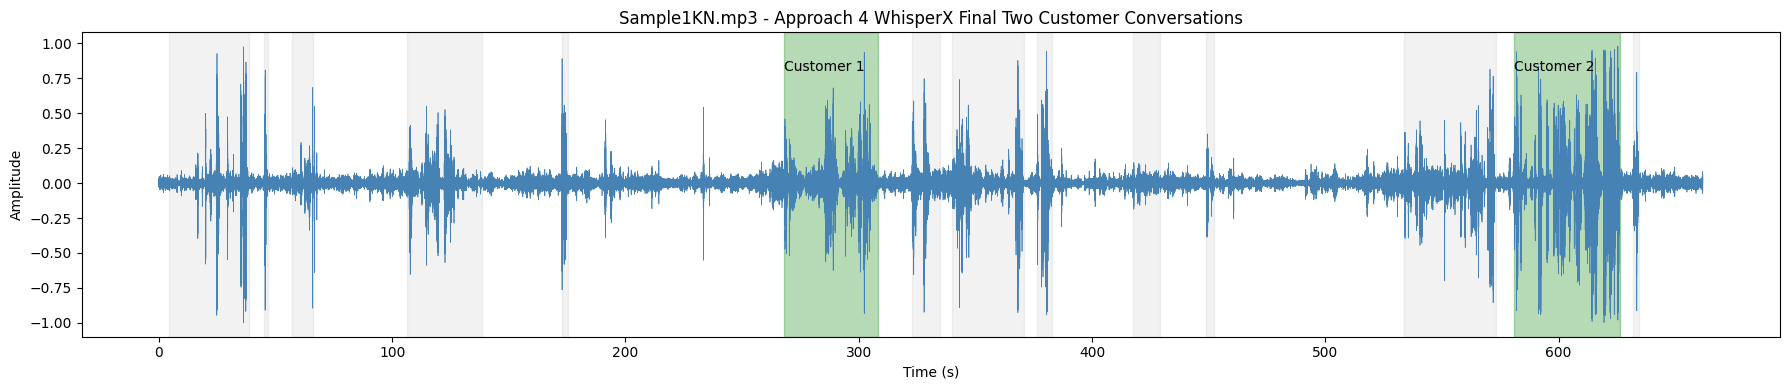

In [10]:
plot_waveform_with_selected_conversations(
    example_result["waveform"],
    example_result["sample_rate"],
    example_result["conversation_candidates"],
    example_result["final_two_conversations"],
    title=f"{example_result['audio_name']} - Approach 4 WhisperX Final Two Customer Conversations",
)

## Standard Outputs

Each approach now writes the same comparable output structure. For each audio file:

- `*_conversation_candidates.csv`: candidate conversation blocks generated by this approach.
- `*_final_two_conversations.csv`: the final predicted two customer conversation windows.
- `*_tagged_conversation_candidates.csv`: the candidate blocks annotated with whether they contributed to customer 1, customer 2, or were not selected.

At the approach folder level:

- `all_files_final_two_conversations.csv`: final predictions across all audio files.
- `evaluation_against_ground_truth.csv`: per-conversation boundary errors and IoU when `ground_truth.json` is available.
- `evaluation_summary.csv`: per-file mean absolute start error, mean absolute end error, and mean IoU.
